# PED Alias Validation

Notebook này kiểm tra riêng alias map của PED trên 2 reference và 100 query records.

Mục tiêu ngắn gọn:

1. Alias config resolve được bao nhiêu raw qualifier names.
2. Tên nào đang canonical / ignored / ambiguous / unresolved.
3. Coverage theo gene sau khi apply alias.

Notebook này **không chạy tblastn**, nên chạy nhanh.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from Bio import SeqIO

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'app' / 'src').exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.src.alias.alias_manager import validate_alias_config
from app.src.alias.gene_alias import (
    AMBIGUOUS_SENTINEL,
    IGNORED_SENTINEL,
    apply_alias_to_features,
    build_alias_lookup,
    load_alias_config,
    lookup_field_value,
)
from app.src.io.genbank_parser import _LOOKUP_QUALIFIER_KEYS, parse_cds_features

DATA_DIR = ROOT / 'app' / 'data' / 'PED'
CONFIG_PATH = ROOT / 'app' / 'config' / 'porcine_epidemic_diarrhea_virus_alias.json'
OUTPUT_DIR = ROOT / 'app' / 'validation' / '06_ped_validation' / 'outputs' / 'alias'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REF_PATHS = [DATA_DIR / 'PED_ref_1.gb', DATA_DIR / 'PED_ref_2.gb']
QUERY_PATH = DATA_DIR / 'PED_100seqs.gb'

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 120)

## Load Data And Alias Config

In [2]:
config = load_alias_config(CONFIG_PATH)
alias_lookup = build_alias_lookup(config)
warnings = validate_alias_config(config)

ref_records = [next(SeqIO.parse(path, 'genbank')) for path in REF_PATHS]
query_records = list(SeqIO.parse(QUERY_PATH, 'genbank'))
all_records = ref_records + query_records

print('Alias config:', CONFIG_PATH)
print('Warnings:', warnings or 'none')
print('Refs:', [record.id for record in ref_records])
print('Query records:', len(query_records))

Alias config: /Users/MacbookProCuaNminh/Desktop/Nminh-Code/Bio-Vin/Phase_2/viralift/app/config/porcine_epidemic_diarrhea_virus_alias.json
Warnings: none
Refs: ['PZ105934.1', 'PV974486.1']
Query records: 100


## Reference Canonical Model

Đây là bộ gene trong 2 reference PED. Alias validation phía dưới sẽ kiểm tra query annotation có map được về các tên này hoặc canonical extra như `ORF1ab` không.

In [3]:
ref_rows = []
for label, record in zip(['ref_1', 'ref_2'], ref_records):
    raw_features = parse_cds_features(record)
    aliased = apply_alias_to_features(raw_features, alias_lookup)
    for feature in aliased:
        ref_rows.append({
            'ref': label,
            'record_id': record.id,
            'name': feature['name'],
            'raw_name': feature.get('raw_name'),
            'source': feature.get('name_source'),
            'start': feature['start'],
            'end': feature['end'],
            'length': feature['end'] - feature['start'] + 1,
            'gene': feature.get('gene'),
            'product': feature.get('product'),
        })
ref_model = pd.DataFrame(ref_rows)
ref_model.to_csv(OUTPUT_DIR / 'ped_ref_model.tsv', sep='	', index=False)
ref_model

,ref,record_id,name,raw_name,source,start,end,length,gene,product
0,ref_1,PZ105934.1,ORF1a,ORF1a,alias,293,12646,12354,ORF1a,polyprotein 1a
1,ref_1,PZ105934.1,ORF1b,ORF1b,alias,12811,20637,7827,ORF1b,polyprotein 1b
2,ref_1,PZ105934.1,S,S,alias,20634,24794,4161,S,spike protein
3,ref_1,PZ105934.1,ORF3,ORF3,alias,24794,25468,675,ORF3,accessory protein 3a
4,ref_1,PZ105934.1,E,E,alias,25449,25679,231,E,envelope protein
5,ref_1,PZ105934.1,M,M,alias,25687,26367,681,M,membrane protein
6,ref_1,PZ105934.1,N,N,alias,26379,27704,1326,N,nucleocapsid protein
7,ref_2,PV974486.1,ORF1a,ORF1a,alias,271,12624,12354,ORF1a,polyprotein 1a
8,ref_2,PV974486.1,ORF1b,ORF1b,alias,12594,20615,8022,ORF1b,polyprotein 1b
9,ref_2,PV974486.1,S,S,alias,20612,24760,4149,S,spike protein


## Raw Qualifier Coverage

Mỗi row là một qualifier value thật trong GenBank (`gene`, `product`, `note`, ...). `resolved_to` cho biết alias map xử lý nó như thế nào.

In [4]:
def classify_resolved(value):
    hit = lookup_field_value(value, alias_lookup)
    if hit == IGNORED_SENTINEL:
        return 'ignored'
    if hit == AMBIGUOUS_SENTINEL:
        return 'ambiguous'
    if hit is None:
        return 'unresolved'
    return hit

rows = []
for dataset, records in [('reference', ref_records), ('query_100', query_records)]:
    for record in records:
        for feature in parse_cds_features(record):
            for field in _LOOKUP_QUALIFIER_KEYS:
                value = feature.get(field)
                if not value:
                    continue
                rows.append({
                    'dataset': dataset,
                    'record_id': record.id,
                    'feature_name_raw': feature.get('name'),
                    'feature_start': feature.get('start'),
                    'feature_end': feature.get('end'),
                    'field': field,
                    'raw_value': value,
                    'resolved_to': classify_resolved(value),
                })

alias_df = pd.DataFrame(rows)
alias_df['status'] = alias_df['resolved_to'].where(
    alias_df['resolved_to'].isin(['ignored', 'ambiguous', 'unresolved']),
    'canonical',
)
alias_df.to_csv(OUTPUT_DIR / 'ped_alias_qualifier_rows.tsv', sep='	', index=False)
alias_df.head(20)

,dataset,record_id,feature_name_raw,feature_start,feature_end,field,raw_value,resolved_to,status
0,reference,PZ105934.1,ORF1a,293,12646,gene,ORF1a,ORF1a,canonical
1,reference,PZ105934.1,ORF1a,293,12646,product,polyprotein 1a,ORF1a,canonical
2,reference,PZ105934.1,ORF1b,12811,20637,gene,ORF1b,ORF1b,canonical
3,reference,PZ105934.1,ORF1b,12811,20637,product,polyprotein 1b,ORF1b,canonical
4,reference,PZ105934.1,S,20634,24794,gene,S,S,canonical
5,reference,PZ105934.1,S,20634,24794,product,spike protein,S,canonical
6,reference,PZ105934.1,ORF3,24794,25468,gene,ORF3,ORF3,canonical
7,reference,PZ105934.1,ORF3,24794,25468,product,accessory protein 3a,ORF3,canonical
8,reference,PZ105934.1,E,25449,25679,gene,E,E,canonical
9,reference,PZ105934.1,E,25449,25679,product,envelope protein,E,canonical


## Overall Alias Coverage

- `canonical_pct`: phần trăm qualifier values map được vào canonical.
- `actionable_coverage_pct`: bỏ qua ignored names khỏi denominator, để xem trong các tên đáng quan tâm thì alias map xử lý được bao nhiêu.


In [5]:
overall = (
    alias_df.groupby('dataset')
    .agg(
        total=('raw_value', 'size'),
        canonical=('status', lambda s: int(s.eq('canonical').sum())),
        ignored=('status', lambda s: int(s.eq('ignored').sum())),
        ambiguous=('status', lambda s: int(s.eq('ambiguous').sum())),
        unresolved=('status', lambda s: int(s.eq('unresolved').sum())),
    )
    .reset_index()
)
overall['canonical_pct'] = (overall['canonical'] / overall['total'] * 100).round(2)
overall['actionable_total'] = overall['total'] - overall['ignored']
overall['actionable_coverage_pct'] = (overall['canonical'] / overall['actionable_total'] * 100).round(2)
overall.to_csv(OUTPUT_DIR / 'ped_alias_overall_summary.tsv', sep='	', index=False)
overall

,dataset,total,canonical,ignored,ambiguous,unresolved,canonical_pct,actionable_total,actionable_coverage_pct
0,query_100,1077,976,95,2,4,90.62,982,99.39
1,reference,28,27,1,0,0,96.43,27,100.00


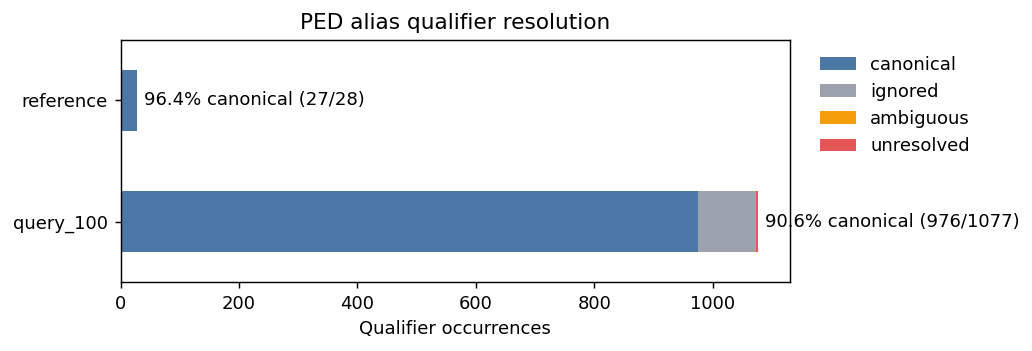

In [6]:
plot_df = overall.set_index('dataset')[['canonical', 'ignored', 'ambiguous', 'unresolved']]
colors = ['#4c78a8', '#9ca3af', '#f59e0b', '#e45756']
ax = plot_df.plot(kind='barh', stacked=True, figsize=(8, 2.8), color=colors)
ax.set_title('PED alias qualifier resolution')
ax.set_xlabel('Qualifier occurrences')
ax.set_ylabel('')
ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
for i, (_, row) in enumerate(plot_df.iterrows()):
    total = row.sum()
    canonical = row['canonical']
    ax.text(total + max(plot_df.sum(axis=1)) * 0.01, i, f'{canonical/total*100:.1f}% canonical ({canonical}/{total})', va='center')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ped_alias_overall_resolution.png', bbox_inches='tight')
plt.show()

## Coverage By Field

Dùng bảng này để biết gap còn lại đến từ field nào (`gene`, `product`, `note`, ...).

In [7]:
by_field = (
    alias_df.groupby(['dataset', 'field', 'status'])
    .size()
    .reset_index(name='count')
    .pivot_table(index=['dataset', 'field'], columns='status', values='count', fill_value=0)
    .reset_index()
)
for col in ['canonical', 'ignored', 'ambiguous', 'unresolved']:
    if col not in by_field:
        by_field[col] = 0
by_field['total'] = by_field[['canonical', 'ignored', 'ambiguous', 'unresolved']].sum(axis=1)
by_field['canonical_pct'] = (by_field['canonical'] / by_field['total'] * 100).round(2)
by_field = by_field[['dataset', 'field', 'total', 'canonical', 'ignored', 'ambiguous', 'unresolved', 'canonical_pct']]
by_field.to_csv(OUTPUT_DIR / 'ped_alias_by_field.tsv', sep='	', index=False)
by_field

status,dataset,field,total,canonical,ignored,ambiguous,unresolved,canonical_pct
0,query_100,gene,408.0,401.0,5.0,2.0,0.0,98.28
1,query_100,note,68.0,65.0,0.0,0.0,3.0,95.59
2,query_100,product,601.0,510.0,90.0,0.0,1.0,84.86
3,reference,gene,14.0,14.0,0.0,0.0,0.0,100.00
4,reference,product,14.0,13.0,1.0,0.0,0.0,92.86


## Feature-Level Canonical Coverage

Bảng này apply alias ở mức feature, giống logic pipeline. Một record có thể có `ORF1ab` thay vì `ORF1a`/`ORF1b`, nên xem theo số record có feature đó.

In [8]:
feature_rows = []
for record in query_records:
    for feature in apply_alias_to_features(parse_cds_features(record), alias_lookup):
        feature_rows.append({
            'record_id': record.id,
            'name': feature['name'],
            'source': feature.get('name_source'),
            'raw_name': feature.get('raw_name'),
            'start': feature['start'],
            'end': feature['end'],
            'gene': feature.get('gene'),
            'product': feature.get('product'),
            'note': feature.get('note'),
        })
features_df = pd.DataFrame(feature_rows)
features_df.to_csv(OUTPUT_DIR / 'ped_alias_feature_rows.tsv', sep='	', index=False)

feature_presence = (
    features_df[features_df['source'].isin(['alias', 'alias_conflict_resolved'])]
    .groupby('name')
    .agg(
        records=('record_id', 'nunique'),
        features=('record_id', 'size'),
        main_source=('source', lambda s: s.value_counts().idxmax()),
    )
    .reset_index()
    .sort_values(['records', 'name'], ascending=[False, True])
)
feature_presence.to_csv(OUTPUT_DIR / 'ped_alias_feature_presence.tsv', sep='	', index=False)
feature_presence

,name,records,features,main_source
0,E,97,97,alias
1,M,97,97,alias
2,N,97,97,alias
7,S,97,97,alias
6,ORF3,92,92,alias
4,ORF1ab,85,88,alias_conflict_resolved
3,ORF1a,17,17,alias
5,ORF1b,8,8,alias


## Names To Review

`unresolved` nên được xem để quyết định thêm alias hay ignore. `ambiguous` là tên cố ý bắt user review, ví dụ `mp` trong PED.

In [9]:
review_names = (
    alias_df[alias_df['status'].ne('canonical')]
    .groupby(['status', 'field', 'raw_value', 'resolved_to'])
    .agg(
        count=('raw_value', 'size'),
        records=('record_id', lambda s: ', '.join(sorted(set(s))[:8]) + (' ...' if s.nunique() > 8 else '')),
    )
    .reset_index()
    .sort_values(['status', 'count'], ascending=[True, False])
)
review_names.to_csv(OUTPUT_DIR / 'ped_alias_names_to_review.tsv', sep='	', index=False)
review_names.head(80)

,status,field,raw_value,resolved_to,count,records
0,ambiguous,gene,mp,ambiguous,2,"LT898413.1, MF577027.1"
4,ignored,product,replicase polyprotein,ignored,35,"LT898413.1, OP894120.1, OR085232.1, OR085240.1, OR085242.1, OR085246.1, OR085251.1, OR085255.1 ..."
2,ignored,product,hypothetical protein,ignored,32,"JX112709.1, JX489155.1, KC210147.1, KM189367.2, KM609208.1, KM609213.1, KP765609.1, KX981440.1 ..."
3,ignored,product,polyprotein,ignored,22,"JX112709.1, KC210147.1, KP765609.1, KX550281.1, KX981440.1, KY007139.1, KY928065.1, KY963963.1 ..."
1,ignored,gene,HNZK1,ignored,5,OQ979200.1
5,ignored,product,unknown,ignored,2,"AF353511.1, EF185992.1"
6,unresolved,note,101-bp deletion results in frameshift and premature termination,unresolved,1,PV533621.1
7,unresolved,note,1a polyprotein and 1b polyprotein,unresolved,1,JX112709.1
8,unresolved,note,contains ORF1a and ORF1b,unresolved,1,KY928065.1
9,unresolved,product,truncated hypothetical protein,unresolved,1,PV533621.1


## Short Takeaway Template

Sau khi chạy notebook, đọc theo thứ tự:

1. `warnings` phải là `none`.
2. `actionable_coverage_pct` càng cao càng tốt.
3. `ORF1ab` nên là canonical riêng, không ép vào `ORF1a`.
4. `HNZK1` nên ignored vì là strain/isolate prefix.
5. `mp` nên ambiguous nếu xuất hiện một mình.
